<a href="https://colab.research.google.com/github/rahitmaity231-lang/AI_LAB/blob/main/Lab1_Q2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

             WATER JUG PROBLEM USING BFS

Jug A Capacity : 4 Litres
Jug B Capacity : 3 Litres
Goal           : Exactly 2 Litres

Minimum Solution:
-----------------------------------------------------------------
Step 0: State = (0, 0)
Step 1: Pour B → A      -> State = (0, 3)
Step 2: Fill Jug B      -> State = (3, 0)
Step 3: Pour B → A      -> State = (3, 3)
Step 4: Goal Reached    -> State = (4, 2)
-----------------------------------------------------------------

Minimum number of operations = 4
Final State = Jug A: 4 L, Jug B: 2 L


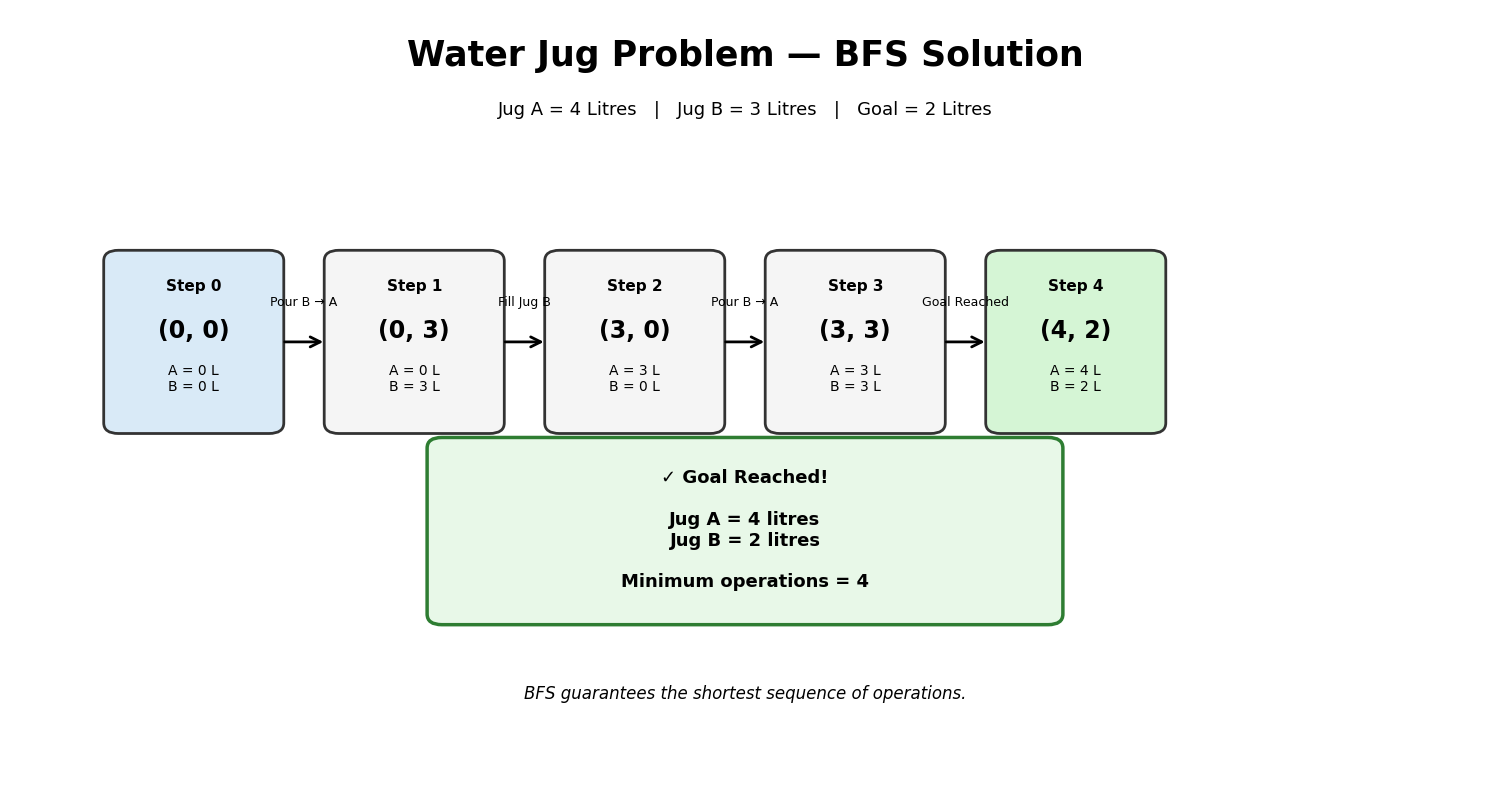

In [ ]:
from collections import deque
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch


# ============================================================
# WATER JUG PROBLEM USING BFS
# Jug A = 4 Litres
# Jug B = 3 Litres
# Goal = Exactly 2 Litres in either jug
# ============================================================

CAPACITY_A = 4
CAPACITY_B = 3


# ============================================================
# 1. GENERATE ALL POSSIBLE NEXT STATES
# ============================================================

def get_next_states(state):
    """
    Given a state (a, b), generate all possible states
    using the allowed water-jug operations.

    Returns:
        List of tuples:
        (new_state, operation_description)
    """

    a, b = state
    states = []

    # --------------------------------------------------------
    # Operation 1: Fill Jug A
    # --------------------------------------------------------
    if a < CAPACITY_A:
        states.append(
            ((CAPACITY_A, b), "Fill Jug A")
        )

    # --------------------------------------------------------
    # Operation 2: Fill Jug B
    # --------------------------------------------------------
    if b < CAPACITY_B:
        states.append(
            ((a, CAPACITY_B), "Fill Jug B")
        )

    # --------------------------------------------------------
    # Operation 3: Empty Jug A
    # --------------------------------------------------------
    if a > 0:
        states.append(
            ((0, b), "Empty Jug A")
        )

    # --------------------------------------------------------
    # Operation 4: Empty Jug B
    # --------------------------------------------------------
    if b > 0:
        states.append(
            ((a, 0), "Empty Jug B")
        )

    # --------------------------------------------------------
    # Operation 5: Pour A -> B
    # --------------------------------------------------------
    amount = min(a, CAPACITY_B - b)

    if amount > 0:
        states.append(
            (
                (a - amount, b + amount),
                "Pour A → B"
            )
        )

    # --------------------------------------------------------
    # Operation 6: Pour B -> A
    # --------------------------------------------------------
    amount = min(b, CAPACITY_A - a)

    if amount > 0:
        states.append(
            (
                (a + amount, b - amount),
                "Pour B → A"
            )
        )

    return states


# ============================================================
# 2. BFS ALGORITHM
# ============================================================

def water_jug_bfs():
    """
    Performs BFS to find the minimum sequence of operations
    required to obtain exactly 2 litres in either jug.
    """

    start = (0, 0)

    # Queue contains:
    # (current_state, path)
    queue = deque()

    queue.append((start, []))

    visited = set()
    visited.add(start)

    while queue:

        current_state, path = queue.popleft()

        a, b = current_state

        # ----------------------------------------------------
        # Goal Test
        # ----------------------------------------------------
        if a == 2 or b == 2:
            return path + [(current_state, "Goal Reached")]

        # ----------------------------------------------------
        # Generate next states
        # ----------------------------------------------------
        for next_state, operation in get_next_states(current_state):

            if next_state not in visited:

                visited.add(next_state)

                new_path = path + [
                    (current_state, operation)
                ]

                queue.append(
                    (next_state, new_path)
                )

    return None


# ============================================================
# 3. SOLVE THE PROBLEM
# ============================================================

solution = water_jug_bfs()


# ============================================================
# 4. PRINT THE SOLUTION
# ============================================================

print("=" * 65)
print("             WATER JUG PROBLEM USING BFS")
print("=" * 65)

print("\nJug A Capacity : 4 Litres")
print("Jug B Capacity : 3 Litres")
print("Goal           : Exactly 2 Litres")
print()

print("Minimum Solution:")
print("-" * 65)

for i, (state, operation) in enumerate(solution):

    if i == 0:
        print(f"Step {i}: State = {state}")

    else:
        print(
            f"Step {i}: {operation:<15} "
            f"-> State = {state}"
        )

print("-" * 65)

print(
    f"\nMinimum number of operations = {len(solution) - 1}"
)

final_state = solution[-1][0]

print(
    f"Final State = Jug A: {final_state[0]} L, "
    f"Jug B: {final_state[1]} L"
)

print("=" * 65)


# ============================================================
# 5. PREPARE STATES FOR VISUALIZATION
# ============================================================

states = [item[0] for item in solution]
operations = [item[1] for item in solution]


# ============================================================
# 6. DRAW BFS SOLUTION PATH
# ============================================================

fig, ax = plt.subplots(figsize=(15, 8))

ax.set_xlim(-1, 7)
ax.set_ylim(-1, 4.8)

ax.axis("off")


# ------------------------------------------------------------
# Main Title
# ------------------------------------------------------------

ax.text(
    3,
    4.45,
    "Water Jug Problem — BFS Solution",
    ha="center",
    va="center",
    fontsize=25,
    fontweight="bold"
)

ax.text(
    3,
    4.05,
    "Jug A = 4 Litres   |   Jug B = 3 Litres   |   Goal = 2 Litres",
    ha="center",
    va="center",
    fontsize=13
)


# ============================================================
# 7. DRAW STATE BOXES
# ============================================================

x_positions = [0, 1.2, 2.4, 3.6, 4.8]

y_position = 2.3

for i, state in enumerate(states):

    x = x_positions[i]

    a, b = state

    # --------------------------------------------------------
    # Determine box appearance
    # --------------------------------------------------------

    if i == 0:
        box_color = "#D9EAF7"
    elif i == len(states) - 1:
        box_color = "#D5F5D5"
    else:
        box_color = "#F5F5F5"

    # --------------------------------------------------------
    # Draw rounded rectangle
    # --------------------------------------------------------

    box = FancyBboxPatch(
        (x - 0.45, y_position - 0.65),
        0.9,
        1.3,
        boxstyle="round,pad=0.04,rounding_size=0.08",
        facecolor=box_color,
        edgecolor="#333333",
        linewidth=2
    )

    ax.add_patch(box)

    # --------------------------------------------------------
    # Step number
    # --------------------------------------------------------

    ax.text(
        x,
        y_position + 0.42,
        f"Step {i}",
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # State
    # --------------------------------------------------------

    ax.text(
        x,
        y_position + 0.08,
        f"({a}, {b})",
        ha="center",
        va="center",
        fontsize=17,
        fontweight="bold"
    )

    # --------------------------------------------------------
    # Jug labels
    # --------------------------------------------------------

    ax.text(
        x,
        y_position - 0.28,
        f"A = {a} L\nB = {b} L",
        ha="center",
        va="center",
        fontsize=10
    )

    # --------------------------------------------------------
    # Arrow to next state
    # --------------------------------------------------------

    if i < len(states) - 1:

        ax.annotate(
            "",
            xy=(x + 0.72, y_position),
            xytext=(x + 0.48, y_position),
            arrowprops=dict(
                arrowstyle="->",
                lw=2,
                mutation_scale=18
            )
        )

        ax.text(
            x + 0.60,
            y_position + 0.25,
            operations[i + 1],
            ha="center",
            va="bottom",
            fontsize=9,
            rotation=0
        )


# ============================================================
# 8. FINAL ANSWER BOX
# ============================================================

final_a, final_b = final_state

answer_text = (
    f"✓ Goal Reached!\n\n"
    f"Jug A = {final_a} litres\n"
    f"Jug B = {final_b} litres\n\n"
    f"Minimum operations = {len(solution) - 1}"
)

answer_box = FancyBboxPatch(
    (1.35, 0.25),
    3.3,
    1.25,
    boxstyle="round,pad=0.08,rounding_size=0.08",
    facecolor="#E8F8E8",
    edgecolor="#2E7D32",
    linewidth=2.5
)

ax.add_patch(answer_box)

ax.text(
    3,
    0.88,
    answer_text,
    ha="center",
    va="center",
    fontsize=13,
    fontweight="bold"
)


# ============================================================
# 9. EXPLANATION
# ============================================================

ax.text(
    3,
    -0.35,
    "BFS guarantees the shortest sequence of operations.",
    ha="center",
    va="center",
    fontsize=12,
    style="italic"
)


plt.tight_layout()

plt.show()